# Suicide Risk Regression - Sweep Analysis

This notebook summarizes the results of hyperparameter sweep `u929626r` for the `suicide_risk_regression` target aggregator. It isolates high-performing data filters and highlights key parameter interaction effects.

## Summary of Sweep Parameters

To understand the results, below is a translation of the technical config parameters into natural, translational modeling and clinical terms, along with the specific configurations swept:

| Translational Parameter Name | Config Parameter | Modeling & Clinical Control | Swept Values |
| :--- | :--- | :--- | :--- |
| **Target Clinical Outcome** | `data/aggregator` | The self-report mental health endpoint the regression model is training to predict. | `positive_emotion_regression`, `self_harm_regression`, `suicide_risk_regression` |
| **Platform Cohort Filter** | `data.os_filter` | Restricts the patient cohort by phone platform. Used to assess if platform-specific sensor tracking differences (e.g., Apple Health vs Google Fit) affect predictive capability. | `ios` (iPhone only), `both` (iPhone + Android) |
| **Daily Survey Aggregation Policy** | `data.collapse_strategy` | Controls how the model handles cases where a subject submits multiple self-report surveys on the same day. | `mean` (average responses to smooth noise), `first` (use the first response of the day), `none` (treat duplicate daily reports as separate samples) |
| **Feature Normalization Strategy** | `data/scaler` | Determines how behavioral features (such as step counts) are normalized. | `standard` (global standardization across the cohort), `subject_standard` (individual standardization per subject to account for personal baseline ranges) |
| **Time-Series Sampling Method** | `data/sampler` | Determines how historical sequences of behavior are grouped and fed into the LSTM. | `block` (discrete, non-overlapping sequential windows), `offset` (rolling, overlapping sliding windows) |
| **Temporal Resolution (Step Size)** | `++data.sampler.resample_freq` | The duration of each individual step in the input sequence. Smaller intervals capture fine-grained patterns, while larger ones yield aggregated trends. | `4h`, `6h`, `12h` |
| **Historical Lookback Window** | `++data.sampler.lookback_days` | The total number of days of history analyzed by the LSTM to make a prediction. | `3`, `5`, `7` days |
| **Prediction Lag (Start Offset)** | `++data.sampler.start_offset_hours` | How far back the behavioral lookback window begins relative to the survey time, defining the historical start boundary. | `-72h` (3 days back), `-120h` (5 days back), `-168h` (7 days back) |

## Target Regression Labeling Logic

To train the regression models, raw multi-question momentary assessment survey answers must be mathematically collapsed into a single continuous score. This is handled by the project's [label_aggregators.py](file:///Users/khickey/Desktop/lemurs/lemurs-modeling/src/data/components/label_aggregators.py) implementation via the `RegressionAggregator` class.

### 1. The Core Aggregation Mechanism
For any given survey submission, the regression target is computed as follows:
* **Target Question Selection**: The aggregator isolates a specific list of question IDs (`likert_ids`) associated with the clinical target.
* **Numeric Mapping**: Answers are cleaned and converted to numeric values (e.g., mapping boolean `"yes"`/`"no"` answers to `1.0`/`0.0` and casting standard strings to floats).
* **Likert Scale Zero-Shifting**: To ensure a baseline score of 0 corresponds to no severity, 1-indexed Likert scales (e.g., 1-5 or 1-7) are shifted by subtracting 1. (The code automatically checks if `0` is present in the dataset to avoid double-shifting).
* **Target Summation**: The shifted scores are summed across the target questions.
* **Missing Data Safety**: The sum requires at least one valid question (`min_count=1`). If all targeted questions for a survey response are missing (NaN), the label is set to NaN rather than defaulting to `0` (which would falsely indicate zero risk).

---

### 2. Specific Target Aggregators in the Sweep

The hyperparameter sweep swept over three clinical target endpoints. The specific summation logic for each target is defined below:

| Target Outcome | Swept Aggregator Value | Targeted Question IDs | Mathematical Logic | Clinical Mapping |
| :--- | :--- | :--- | :--- | :--- |
| **Suicide Risk** | `suicide_risk_regression` | `[2, 3, 5, 7]` | $\sum_{q \in \{2,3,5,7\}} (\text{Score}_q - 1)$ | Sums Likert-scale questions regarding active suicidal ideation and self-harm desires, excluding binary/conditional questions. |
| **Self-Harm** | `self_harm_regression` | `[9]` | $(\text{Score}_9 - 1)$ | Sums Likert-scale questions explicitly measuring recent self-harm frequencies or behaviors. |
| **Positive Emotion** | `positive_emotion_regression` | `[21, 22, 37]` | $\sum_{q \in \{21,22,37\}} (\text{Score}_q - 1)$ | Sums Likert-scale mood descriptors capturing positive affect/emotion to model protective factors. |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rootutils

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
palette = sns.color_palette("coolwarm", as_cmap=False)

# Load data
root_dir = rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)
csv_path = os.path.join(root_dir, "notebooks", "sweep_u929626r_data.csv")
df = pd.read_csv(csv_path)

agg_col = "config/data/aggregator"
mse_col = "metric/val/mse"

df_suicide = df[df[agg_col] == "suicide_risk_regression"].copy()
df_suicide[mse_col] = pd.to_numeric(df_suicide[mse_col], errors='coerce')
df_suicide = df_suicide.dropna(subset=[mse_col])
print(f"Loaded {len(df_suicide)} runs for suicide_risk_regression.")

Loaded 641 runs for suicide_risk_regression.


## 1. Main Effect: OS Filter

Filtering the cohort to only include **iOS** users results in a huge performance boost compared to using **both** iOS and Android data. This is likely due to platform differences in sensor data coverage (e.g., steps). 

/var/folders/n1/bg33hm2s00xg_3v_tfy_fqjm0000gn/T/ipykernel_31214/3665136061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_suicide, x="config/data.os_filter", y="metric/val/mse", palette="Set2")


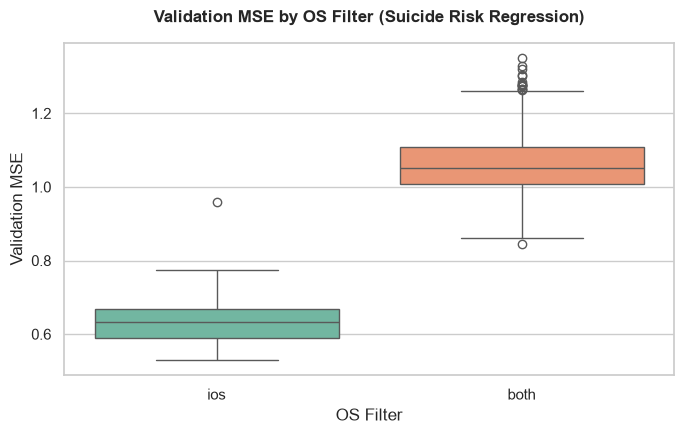

In [2]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df_suicide, x="config/data.os_filter", y="metric/val/mse", palette="Set2")
plt.title("Validation MSE by OS Filter (Suicide Risk Regression)", weight='bold', pad=15)
plt.xlabel("OS Filter")
plt.ylabel("Validation MSE")
plt.tight_layout()
plt.show()

## 2. Main Effect: Collapse Strategy (iOS Runs Only)

Taking the daily **mean** of survey responses (when a user submits multiple responses in one day) yields significantly lower validation MSE than taking the **first** response or doing **no collapse** at all.

/var/folders/n1/bg33hm2s00xg_3v_tfy_fqjm0000gn/T/ipykernel_31214/1052260045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ios, x="config/data.collapse_strategy", y="metric/val/mse", estimator=np.mean, errorbar="sd", palette="Set3")


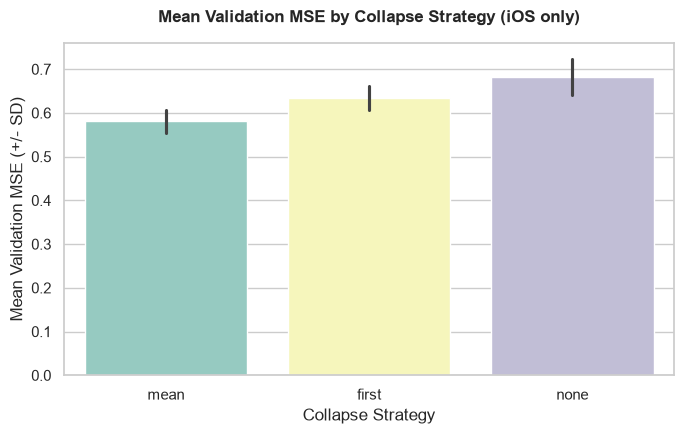

In [3]:
df_ios = df_suicide[df_suicide["config/data.os_filter"] == "ios"]
plt.figure(figsize=(7, 4.5))
sns.barplot(data=df_ios, x="config/data.collapse_strategy", y="metric/val/mse", estimator=np.mean, errorbar="sd", palette="Set3")
plt.title("Mean Validation MSE by Collapse Strategy (iOS only)", weight='bold', pad=15)
plt.xlabel("Collapse Strategy")
plt.ylabel("Mean Validation MSE (+/- SD)")
plt.tight_layout()
plt.show()

## 3. Interaction Effect: Scaler x Sampler (iOS + Mean Collapse runs only)

Isolating runs to the best settings (**iOS** and **Mean Collapse**), we look at how the Scaler and Sampler interact.

There is a **strong interaction**: `subject_standard` standardisation works exceptionally well when paired with the `block` sampler (mean MSE **`0.5632`**), but is the *worst* configuration when paired with the `offset` sampler (mean MSE **`0.5896`**).

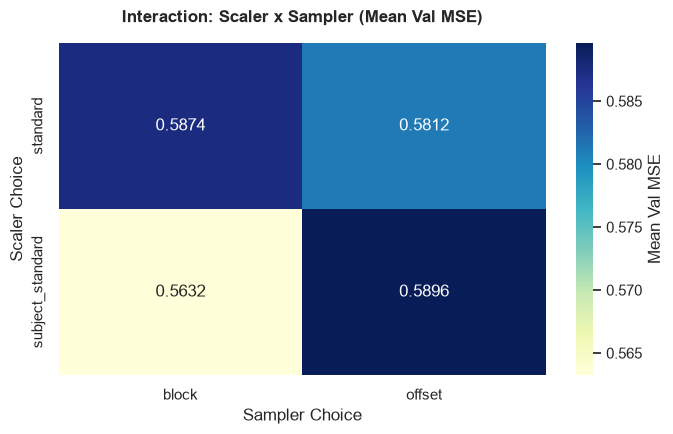

In [4]:
df_best = df_ios[df_ios["config/data.collapse_strategy"] == "mean"]
interaction = df_best.groupby(["config/data/scaler", "config/data/sampler"])[mse_col].mean().unstack()

plt.figure(figsize=(7, 4.5))
sns.heatmap(interaction, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean Val MSE'}, annot_kws={"size": 12})
plt.title("Interaction: Scaler x Sampler (Mean Val MSE)", weight='bold', pad=15)
plt.xlabel("Sampler Choice")
plt.ylabel("Scaler Choice")
plt.tight_layout()
plt.show()

## 4. Interaction Effect: Resample Freq x Start Offset Hours

Analyzing how sampling frequency and start offsets interact. Resampling at a `6h` or `12h` frequency works best. A granular `4h` resampling rate performs worst across all offsets.

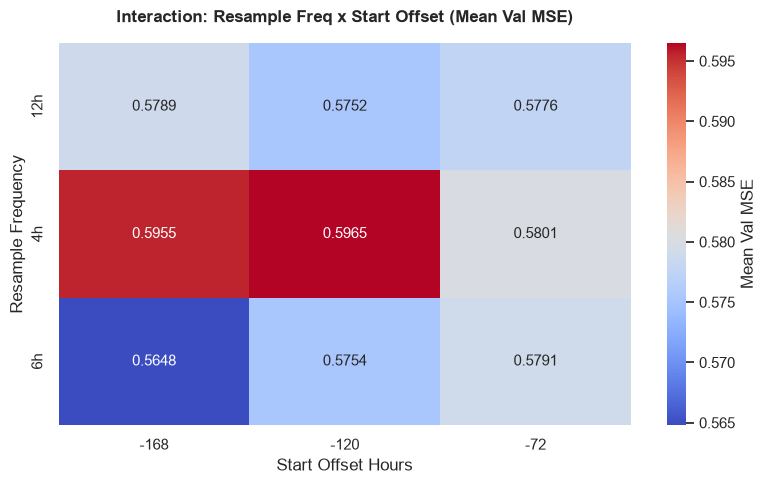

In [5]:
interaction_freq = df_best.groupby(["config/++data.sampler.resample_freq", "config/++data.sampler.start_offset_hours"])[mse_col].mean().unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(interaction_freq, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'Mean Val MSE'}, annot_kws={"size": 11})
plt.title("Interaction: Resample Freq x Start Offset (Mean Val MSE)", weight='bold', pad=15)
plt.xlabel("Start Offset Hours")
plt.ylabel("Resample Frequency")
plt.tight_layout()
plt.show()

## 5. Non-Minimum Values Performance (val/mae_non_min)

The target variable (suicide risk) typically has a high proportion of minimum values (e.g., zeros). Analyzing the predicting non-minimum values performance (`val/mae_non_min`) allows us to see how well the model predicts actual clinical elevations rather than just predicting the baseline baseline score.

Let's look at how the main filters and hyperparameters affect predicting non-minimum values.

/var/folders/n1/bg33hm2s00xg_3v_tfy_fqjm0000gn/T/ipykernel_31214/1452541641.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_suicide_mae, x="config/data.os_filter", y=mae_non_min_col, palette="Set2", ax=axes[0])
/var/folders/n1/bg33hm2s00xg_3v_tfy_fqjm0000gn/T/ipykernel_31214/1452541641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ios_mae, x="config/data.collapse_strategy", y=mae_non_min_col, estimator=np.mean, errorbar="sd", palette="Set3", ax=axes[1])


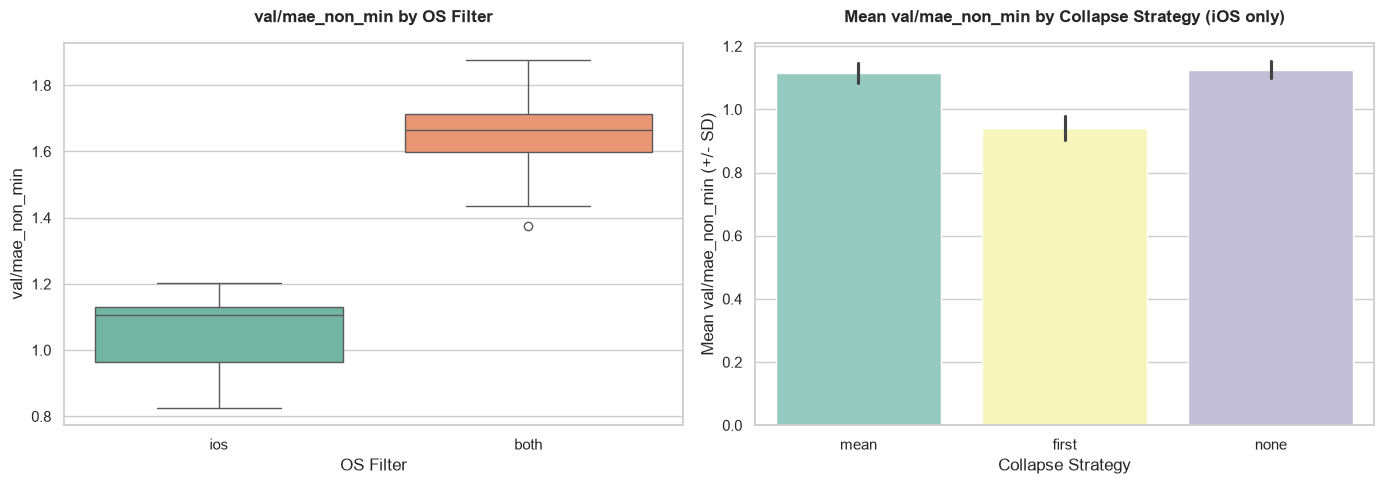

In [6]:
mae_non_min_col = "metric/val/mae_non_min"
df_suicide_mae = df_suicide.dropna(subset=[mae_non_min_col]).copy()
df_suicide_mae[mae_non_min_col] = pd.to_numeric(df_suicide_mae[mae_non_min_col], errors='coerce')

# Plot OS Filter Impact on val/mae_non_min
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_suicide_mae, x="config/data.os_filter", y=mae_non_min_col, palette="Set2", ax=axes[0])
axes[0].set_title("val/mae_non_min by OS Filter", weight='bold', pad=15)
axes[0].set_xlabel("OS Filter")
axes[0].set_ylabel("val/mae_non_min")

# Plot Collapse Strategy Impact on val/mae_non_min (iOS only)
df_ios_mae = df_suicide_mae[df_suicide_mae["config/data.os_filter"] == "ios"]
sns.barplot(data=df_ios_mae, x="config/data.collapse_strategy", y=mae_non_min_col, estimator=np.mean, errorbar="sd", palette="Set3", ax=axes[1])
axes[1].set_title("Mean val/mae_non_min by Collapse Strategy (iOS only)", weight='bold', pad=15)
axes[1].set_xlabel("Collapse Strategy")
axes[1].set_ylabel("Mean val/mae_non_min (+/- SD)")

plt.tight_layout()
plt.show()

### Scaler x Sampler Interaction for val/mae_non_min (iOS + Mean Collapse runs only)

Let's see if the same `subject_standard` + `block` interaction holds for predicting non-minimum values.

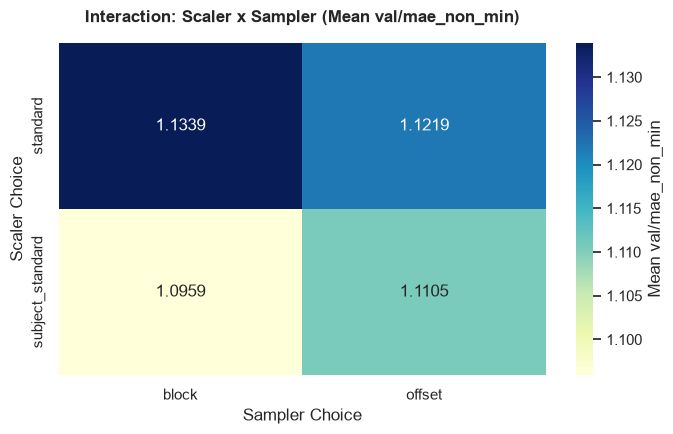

In [7]:
df_best_mae = df_ios_mae[df_ios_mae["config/data.collapse_strategy"] == "mean"]
interaction_mae = df_best_mae.groupby(["config/data/scaler", "config/data/sampler"])[mae_non_min_col].mean().unstack()

plt.figure(figsize=(7, 4.5))
sns.heatmap(interaction_mae, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean val/mae_non_min'}, annot_kws={"size": 12})
plt.title("Interaction: Scaler x Sampler (Mean val/mae_non_min)", weight='bold', pad=15)
plt.xlabel("Sampler Choice")
plt.ylabel("Scaler Choice")
plt.tight_layout()
plt.show()

### Top 10 Configurations for val/mae_non_min (iOS + Mean Collapse)

Here are the top-performing run configurations specifically optimizing for non-minimum value prediction (`val/mae_non_min`).

In [8]:
cols_to_print_mae = ["run_name", mae_non_min_col, "metric/val/mse", "config/data/scaler", "config/data/sampler", "config/++data.sampler.lookback_days", "config/++data.sampler.resample_freq"]
df_top_mae = df_best_mae.sort_values(by=mae_non_min_col)[cols_to_print_mae].head(10).copy()
df_top_mae.columns = [c.split("/")[-1].split(".")[-1] for c in cols_to_print_mae]
df_top_mae

,run_name,mae_non_min,mse,scaler,sampler,lookback_days,resample_freq
1881,dazzling-sweep-1882,1.017251,0.564225,subject_standard,block,7,12h
154,dark-sweep-155,1.042207,0.545860,standard,offset,3,4h
441,sage-sweep-442,1.050903,0.554872,subject_standard,block,3,12h
1305,elated-sweep-1306,1.058637,0.557271,subject_standard,block,7,4h
1882,glorious-sweep-1883,1.060384,0.540631,standard,offset,7,12h
1667,efficient-sweep-1668,1.065050,0.582191,subject_standard,offset,7,6h
1307,effortless-sweep-1307,1.066788,0.613872,standard,offset,7,4h
8,wise-sweep-9,1.068551,0.559760,standard,block,3,4h
800,grateful-sweep-802,1.072182,0.558670,subject_standard,block,5,4h
1019,devout-sweep-1020,1.078558,0.552508,subject_standard,offset,5,6h


## 6. Top 10 Configurations for val/mse (iOS + Mean Collapse)

Here are the absolute top-performing run configurations optimizing for overall MSE (`metric/val/mse`).

In [9]:
cols_to_print = ["run_name", mse_col, "metric/val/mae_non_min", "config/data/scaler", "config/data/sampler", "config/++data.sampler.lookback_days", "config/++data.sampler.resample_freq", "config/++data.sampler.start_offset_hours"]
df_top = df_best.sort_values(by=mse_col)[cols_to_print].head(10).copy()
df_top.columns = [c.split("/")[-1].split(".")[-1] for c in cols_to_print]
df_top

,run_name,mse,mae_non_min,scaler,sampler,lookback_days,resample_freq,start_offset_hours
1809,dainty-sweep-1810,0.529227,1.109014,subject_standard,block,7,12h,-120
369,swift-sweep-370,0.536651,1.080942,subject_standard,block,3,6h,-168
371,rare-sweep-372,0.538110,1.080552,subject_standard,offset,3,6h,-168
1882,glorious-sweep-1883,0.540631,1.060384,standard,offset,7,12h,-168
944,comfy-sweep-946,0.540992,1.109527,subject_standard,block,5,6h,-120
368,flowing-sweep-369,0.541842,1.084066,standard,block,3,6h,-168
731,jolly-sweep-731,0.542189,1.079677,standard,offset,5,4h,-120
154,dark-sweep-155,0.545860,1.042207,standard,offset,3,4h,-168
1017,colorful-sweep-1018,0.551986,1.096729,subject_standard,block,5,6h,-168
1019,devout-sweep-1020,0.552508,1.078558,subject_standard,offset,5,6h,-168
